In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math as math

In [4]:
atoms = 2000
Temp = 15000
kb = 1.38e-23
NA = 6.022e23
MSI = 28.0855/NA #use cgs system
angle = 0.3 #radians
sinangle = math.sin(angle)
cosangle = math.cos(angle)


def trajtoarr(filename, dt,atoms=2000):
    timeflag =False
    atomflag=False
    count = 0
    atomlist = []
    tempatomlist=[]
    timestep=0
    with open(filename, 'r') as file:
        for line in file:
            if "ITEM" in line:
                if "ITEM: TIMESTEP" in line:
                    count += 1
                    timeflag = True
                    atomflag=False
                    tempatomlist.append(float(dt*timestep))
                    atomlist.append(tempatomlist)
                    tempatomlist=[]
                elif "ITEM: ATOMS id type vx vy vz" in line:
                    atomflag = True
                    timeflag=False
                else:
                    timeflag = False
                    atomflag = False
            if timeflag and ("ITEM" not in line):
                timestep = float(line.strip())
            if atomflag and ("ITEM" not in line):
                vz = float(line.strip().split(" ")[-1])
                vy = float(line.strip().split(" ")[-2])
                tempatomlist.append(sinangle*vy+cosangle*vz)
                count += 1
    tempatomlist.append(float(dt*timestep))
    atomlist.append(tempatomlist)
    atomlist.pop()
    atomlist.pop(0)
    atomlist.pop()
    atomarr = np.array(atomlist)
    print(atomarr)
    return atomarr
def logtoarr(filename):
    startlogstr = "   Step          Time           Temp         c_tempH        c_tempSi        TotEng         PotEng         KinEng         Press           v_k0           v_dt        v_collfreq       v_ccs "
    endlogstr = "Loop time of "
    templist=[]
    dataflag=False
    with open(filename, 'r') as file:
        for line in file:
            if  "ERROR" in list(filter(None, line.split(" "))):
                break
            if dataflag:
                dataline = list(filter(None, line.split(" ")))
                dataline[-1] = dataline[-1][:-1]
                dataline = list(filter(None, dataline))
                templist.append(dataline)
            if startlogstr in line:
                dataflag=True
                templist=[]
            if endlogstr in line:
                dataflag=False
    print(templist)

    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop(0)    # print(templist
    return np.array(templist,dtype=np.float64)


runlist = ["run10_15","run10_15b","run10_17","run10_18","run10_19","run10_22","run10_28","run11_5"]
drop22 = [[0,0],[1,0],[4,0],[5,0],[6,0],[7,0],[8,0],[9,0]]
drop28=[]
for i in range(10):
    for j in range(1,4):
        drop22.append([i,j])
for i in range(2):
    for j in range(1,4):
        drop28.append([i,j])
drop115=[]
for i in range(2):
    for j in range(1,4):
        drop115.append([i,j])
dropdict = {"run10_15":[[0,0],[0,1],[0,2],[1,2],[3,2],[4,2],[5,0],[5,1],[5,2],[5,3]],"run10_15b":[[0,0],[1,1],[1,2],[1,3],[2,0],[2,2],[2,3],[3,2],[3,3],[4,1],[4,2],[5,1],[5,2]],"run10_17":[[0,0],[1,3],[3,0],[3,1],[4,1],[4,2],[4,3],[5,1],[5,3],[6,2],[6,3]],"run10_18":[[0,2],[0,3],[1,0],[1,1],[3,2],[4,2],[5,1],[5,3]],"run10_19":[[0,0],[1,0],[1,1],[5,1]],"run10_22":drop22,"run10_28":drop28,"run11_5":drop115}#[[0,2],[1,0]]

thermdict = {"run10_15":81,"run10_15b":81,"run10_17":81,"run10_18":81,"run10_19":21,"run10_22":21,"run10_28":21,"run11_5":21}
veldict = {"run10_15":[2e7,3e7,4e7,5e7,6e7,8e7],"run10_15b":[1e2,1e3,1e4,1e5,1e6,1e7,1e8],"run10_17":[1.5e7,2e6,2.5e7,3e6,3.5e7,4.5e7,6e6,8e6],"run10_18":[1.5e6,2.5e6,4e6,5e6,7e6,9e6],"run10_19":[1.1e7,1.2e7,1.3e7,1.5e7,1.7e7,8e6],"run10_22":[1e4,1e5,1e7,1e8,2e5,2e6,3e5,3e6,6e5,6e6],"run10_28":[1e6,1e7],"run11_5":[3e6,3e7]}
for k in range(7,len(runlist)):
    run = runlist[k]
    print(run)
    thermsteps =thermdict[run]
    velarr = veldict[run]
    casearr = np.array([0,1,2,3])
    folder = "../dataarchive/"+run
    for i in range(len(velarr)):
        for j in range(len(casearr)):
            if [i,j] in dropdict[run]:
                print("drop v{:.1e} c{}".format(velarr[i],casearr[j]))
            if  [i,j] not in dropdict[run]:
                print(i,j)
                vel = velarr[i]
                case = casearr[j]
                datai = logtoarr(folder+"/unforcedvel_v{:.1e}_c{}.log".format(vel,case))
                dt = (datai[1,1]-datai[0,1])/100
                trajarr = trajtoarr(folder+"/trajvel_v{:.1e}_c{}.txt".format(vel,case),dt,atoms=atoms)
                np.savetxt("../dataarchive/np{}/log_v{:.1e}_c{}.np".format(run,vel,case),datai)
                np.savetxt("../dataarchive/np{}/force_v{:.1e}_c{}.np".format(run,vel,case),trajarr)





run11_5
0 0
[['0', '0', '5000', '5000.8665', '4785.7753', '5.7988375e-07', '6.0069906e-08', '5.1981384e-07', '4659960.1', '1155861.6', '1.3412263e-14', '1.4088858e+09', '5.45556e-17'], ['100', '1.3412263e-12', '5167.3476', '5169.1092', '4729.3262', '5.9700384e-07', '5.9792076e-08', '5.3721176e-07', '4796210.9', '1155861.6', '1.3412263e-14', '1.4088858e+09', '5.45556e-17'], ['200', '2.6824527e-12', '5098.6195', '5100.3962', '4656.7548', '5.8979858e-07', '5.9731991e-08', '5.3006659e-07', '4739294.8', '1155861.6', '1.3412263e-14', '1.4088858e+09', '5.45556e-17'], ['300', '4.023679e-12', '5224.788', '5227.3809', '4578.8381', '6.0292967e-07', '5.9746256e-08', '5.4318342e-07', '4843199.4', '1155861.6', '1.3412263e-14', '1.4088858e+09', '5.45556e-17'], ['400', '5.3649053e-12', '5140.0485', '5142.691', '4481.6805', '5.9411133e-07', '5.973766e-08', '5.3437367e-07', '4773422.8', '1155861.6', '1.3412263e-14', '1.4088858e+09', '5.45556e-17'], ['500', '6.7061316e-12', '5426.8489', '5431.0582', '437

# plot 

run10_28
0 0
[997890.75388748 997252.87256624 996708.32489439 996004.31926763
 995286.97967034 994593.40581636 993883.7667326  993153.96289014
 992434.88648324 991672.90856451 991047.19242372 990291.81097257
 989856.6629909  989117.67231224 988397.24569628]


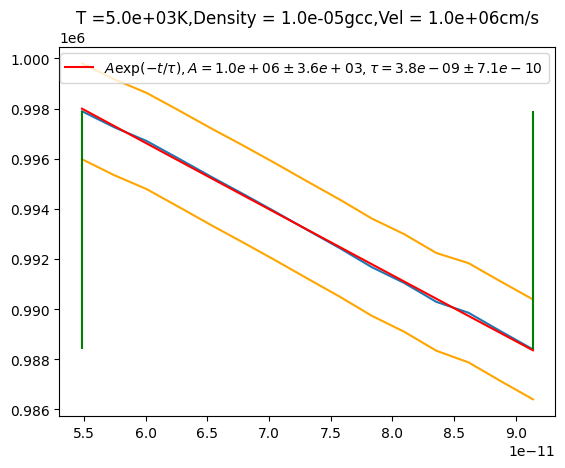

1 0
[9998010.28777546 9997996.49643761 9998017.97140229 9998008.31367507
 9998020.08324292 9998032.36377714 9998043.04947643 9998052.44906244
 9998056.71586106 9998072.06848738 9998102.45683554 9998059.20383416
 9998036.54278436 9998021.05544092 9998002.49467759 9998012.62313102
 9997959.43722845 9997974.47582475 9997995.32307797 9998055.21583544
 9998063.68677865 9998051.53650192 9998040.75712296 9998083.5657922
 9998066.64573779 9997680.85227415 9997632.4275041  9997508.78590094
 9997535.13920892 9997554.76044105 9997554.58954445 9997533.57543626
 9997545.70172799 9997561.01283576 9997555.17522864 9997604.83951986
 9997656.64652722 9997645.45208976 9997634.98001185 9997617.12377935
 9997630.0336271  9997633.72049372 9997649.36848119 9997685.62428402
 9997696.8568817  9997707.89048902 9997676.02142401 9997698.98948732
 9997695.27868773 9997758.80477587 9997725.06808761 9997707.10105537
 9997716.05231401 9997690.1620864  9997724.1829669  9997771.99612775
 9997779.55381948 9997775.06991

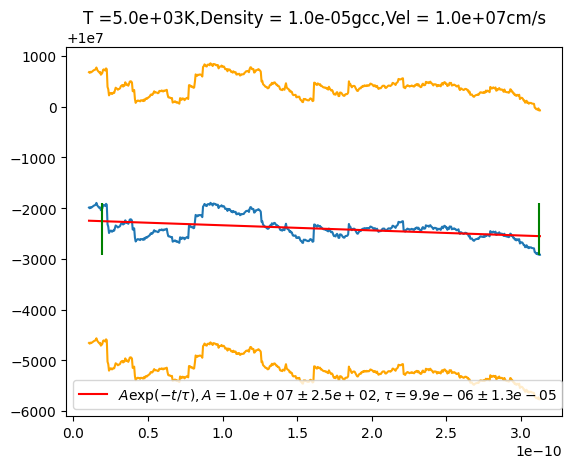

run11_5
0 0
[2998817.19079881 2998768.78105935 2998675.38469754 2998594.99797268
 2998485.27244611 2998486.26018967 2998375.76568721 2998165.8623427
 2998095.51769416 2997968.57038484 2997953.5363907  2997835.02810794
 2997834.33991514 2997674.01394188 2997584.08812257 2997493.27567812
 2997457.85771047 2997291.34454321 2997191.02404841 2997121.32438708
 2997037.8601172  2996971.24859689 2997038.85905538 2997027.44394388
 2996978.20690085 2996861.03951949 2996752.58374633 2996724.84174434
 2996664.22200143 2996532.18126099 2996585.25837011 2996475.88700798
 2996405.25514501 2996400.53290793 2996388.83322157 2996292.0761609
 2996128.55525875 2996417.52597261 2996350.56149387 2996316.56373779
 2996304.40896154 2996368.2892861  2996256.82297358 2996251.99975509
 2996170.25549649 2995996.79771962 2995923.09713581 2995881.01291532
 2995869.05288061 2995871.20364041 2995841.94007979 2995905.73103202
 2995768.96504399 2995728.65973406 2995699.58845209 2995569.41186342
 2995555.09054713 299552

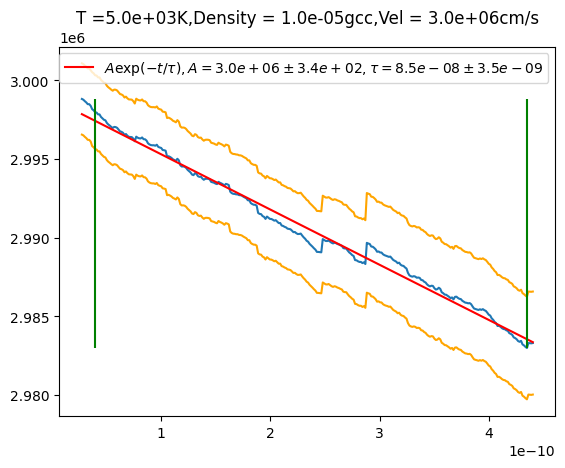

1 0
[29998086.0692561  29998075.47805122 29998071.20214138 ...
 29995825.3977416  29995823.77017712 29995824.0834829 ]


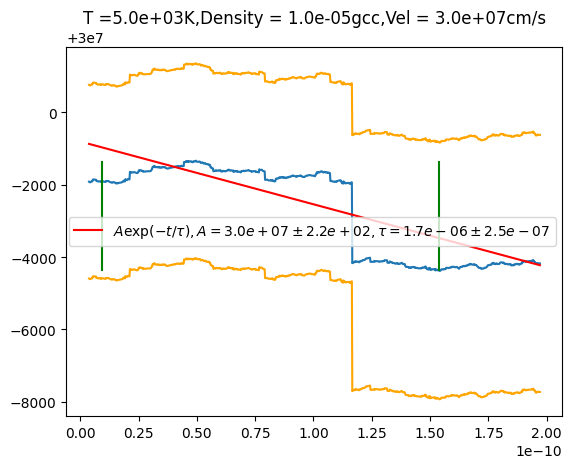

In [5]:
gccarr =  np.array([1e-5,1,1e-5,1])
Tarr = np.array([5000,5000,1e5,1e5])
Z1arr = np.array([0.16,0.65,0.93,0.68])
Z2arr = np.array([0.26,3.82,4.27,3.81])
from scipy.optimize import curve_fit

def exp(time,m,b):
    return b*np.exp(-time/m)
for k in range(6,len(runlist)):
    run = runlist[k]
    print(run)
    folder = "../dataarchive/np{}/".format(runlist[k])
    velarr = veldict[run]
    results = -1*np.ones((4,len(velarr),6)) #4 cases, velocities, A, Aerr, tau, tauerr, start time, end time
    skip = thermdict[run]

    for i in range(len(velarr)):
        for j in range(len(casearr)):
            if  [i,j] not in dropdict[run]:
                print(i,j)
                vel = velarr[i]
                case = casearr[j]
                log = np.loadtxt(folder+"log_v{:.1e}_c{}.np".format(vel,case))
                force = np.loadtxt(folder+"force_v{:.1e}_c{}.np".format(vel,case))
                time = force[skip:,-1]
                data = force[skip:,:-1]
                plt.title("T ={:.1e}K,Density = {:.1e}gcc,Vel = {:.1e}cm/s".format(Tarr[j],gccarr[j],velarr[i]))
                mean = np.mean(data,axis=1)

                starti = min(np.argmin(np.abs(0.999*mean[0]-mean)),int(0.03*len(mean)))
                endi = max(np.argmin(np.abs(0.93*mean[0]-mean)),int(0.08*len(mean)))
                std = np.std(data,axis=1)/math.sqrt(2000)
                dt0 = time[-1]-time[0]
                plt.plot(time,mean)
                print(mean)
                popt, pcov = curve_fit(exp,time[starti:endi],mean[starti:endi],sigma =std[starti:endi],p0=[dt0,mean[0]*math.exp(-time[0]/dt0)],absolute_sigma=True,maxfev=2000)
                errors = np.sqrt(np.diag(pcov))
                results[j,i,:] = [popt[1],errors[1],popt[0],errors[0],time[starti],time[endi]]
                plt.plot(time,mean+std,color="orange")
                plt.plot(time,mean-std,color="orange")
                plt.plot(time,exp(time,popt[0],popt[1]),color="red",label=r"$A\exp(-t/\tau),A = {:.1e}\pm {:.1e}, \tau = {:.1e}\pm {:.1e}$".format(popt[1],errors[1],popt[0],errors[0]))
                plt.vlines([time[starti],time[endi]],ymin=np.min(mean),ymax=np.max(mean),color="green")
                plt.legend()
                plt.show()
    np.save("../dataarchive/np{}/results".format(run),results)

$$ v = A \exp(-t/\tau)$$
$$ a = -v/\tau$$
$$(\Delta v)^2 = \exp(-2t/\tau) (\Delta A^2) + \frac{t^2A^2}{\tau^4} \exp(-2t/\tau) (\Delta \tau^2)$$
$$(\Delta v)^2 = \frac{v^2}{A^2} (\Delta A^2) + \frac{t^2v^2}{\tau^4}  (\Delta \tau^2)$$
$$(\frac{\Delta a}{a})^2 = (\frac{\Delta v}{v})^2 + (\frac{\Delta \tau}{\tau})^2$$

# Overall Plot

C:\Users\shaoq\AppData\Local\Temp\ipykernel_26952\2146157646.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))*dvrel#/np.sum(frel(vrel,vb,T))


run10_19
[[[-1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
   -1.00000000e+00 -1.00000000e+00]
  [-1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
   -1.00000000e+00 -1.00000000e+00]
  [ 1.29981856e+07  7.91110588e+02  3.16853225e-06  2.17969454e-04
    8.98873074e-13  4.37712106e-12]
  [ 1.49981914e+07  7.77490012e+02  1.63017070e-06  5.52056801e-05
    7.87295336e-13  3.90224645e-12]
  [ 1.69981899e+07  7.41708921e+02  2.17230191e-04  1.04418172e+00
    1.00486333e-12  1.64432182e-12]
  [ 7.99813950e+06  3.15644131e+02  1.53575123e-06  6.41843710e-06
    1.93684342e-12  2.41500164e-11]]

 [[ 1.27392379e+07  6.93367067e+03  1.38429157e-13  3.96242816e-16
    2.06607870e-14  4.62408090e-14]
  [-1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
   -1.00000000e+00 -1.00000000e+00]
  [ 1.44649556e+07  6.50179421e+03  1.62845766e-13  5.26864672e-16
    1.77326810e-14  4.05318422e-14]
  [ 1.62372132e+07  6.15023580e+03  1.91172950e-13  6.89985951

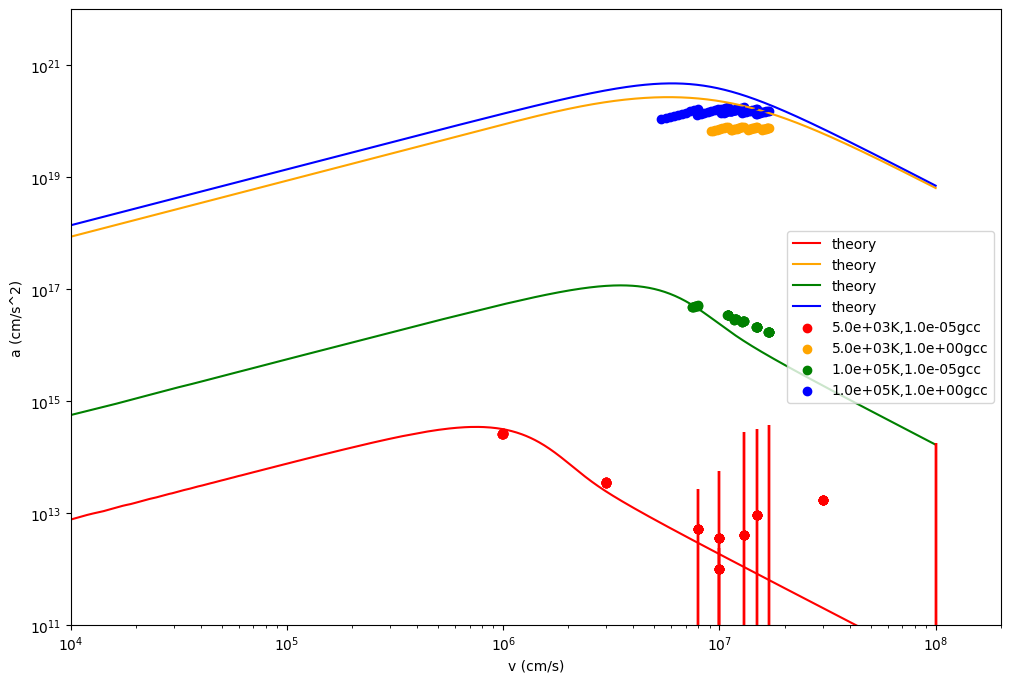

In [6]:
import scipy as scp
NA = 6.022e23
pi = 3.1415926535
me = 9.11e-31 #electron mass
ms = 28.0855*0.001/NA #silicon mass kg
mh = 1.008*0.001/NA
mu = ms*mh/(ms+mh)
qe = 1.6e-19
hbar = 6.626e-34
kb = 1.38e-23
e0 =  8.854e-12
#exp(-Ax)/x = B
#x = W(a/b)/a
Z1arr = np.array([0.16,0.65,0.93,0.68])
Z2arr = np.array([0.26,3.82,4.27,3.81])
def ccs2(vrel,T,gcc,z1=0.648,z2=3.84):# use kinetic energy difference
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31 #electron mass
    ms = 28.0855*0.001/NA
    mh = 1.008*0.001/NA
    mu = ms*mh/(ms+mh)
    qe = 1.6e-19
    hbar = 6.626e-34
    kb = 1.38e-23
    e0 =  8.854e-12
    vcom =  mh*vrel/(mh+ms)
    ne =1e6* NA*z1*gcc/1.008
    ve = np.sqrt(3*kb*T/me)
    wp = np.sqrt(ne*(qe**2)/(me*e0))
    lD = ve/wp
    Tf = ((3*ne*(pi**2))**(2/3))*(hbar**2)/(2*me*kb)
    lS = lD*np.power(1+(2*Tf/(3*T)),1/4)
    k0 = 1/lS
    Aarr = (qe**2)*z1*z2/(4*pi*e0)
    #kinetic energy available is velocity relative to COM
    Barr = 0.5*mh*((vrel-vcom)**2)+0.5*ms*((vcom)**2)
    Carr = Barr/Aarr
    rc = scp.special.lambertw(k0/Carr)/k0
    return pi*rc**2


def frel(vrel,vb,T):
    mu = ms*mh/(ms+mh)
    return np.sqrt(mu/(2*pi*kb*T))*np.exp(-mu*np.square(vrel-vb)/(2*kb*T))

def FDint(vbarr,A,T,gcc,zh,zs): #return drag force in newtons, input velocity in meters per second
    mu = ms*mh/(ms+mh)
    n =1e6* NA*gcc/1.008
    std = np.sqrt(kb*T/mu)
    result = np.zeros(len(vbarr))
    for i in range(len(vbarr)):
        vb = vbarr[i]
        vrel = np.linspace(vb-8*std,vb+8*std,2000)
        dvrel = vrel[1]-vrel[0]
        ccs = A*ccs2(vrel,T,gcc,zh,zs)
        result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))*dvrel#/np.sum(frel(vrel,vb,T))
    return result

gccarr =  np.array([1e-5,1,1e-5,1])
Tarr = np.array([5000,5000,1e5,1e5])
plt.figure(figsize=(12,8))
def exp(time,tau,A):
    return A*np.exp(-time/tau)
colors=["red","orange","green","blue"]
labelled = [False,False,False,False]
xarr = np.logspace(4,8,1000)
for i in range(4):
    plt.plot(xarr,100*np.abs(FDint(xarr/100,1,Tarr[i],gccarr[i],Z1arr[i],Z2arr[i]))/ms,color=colors[i],label="theory")

count=0
for k in range(4,len(runlist)):
    run = runlist[k]
    print(run)
    results = np.load("../dataarchive/np{}/results.npy".format(run))
    print(results)
    velarr = veldict[run]
    for i in range(4):
        for j in range(len(velarr)):
            print(results)
            if results[i,j,5] !=-1:
                count+=1
                casen = casearr[i]
                vel = velarr[j]
                startt = results[i,j,4]
                endt = results[i,j,5]
                tarr = np.linspace(startt,endt,10)
                A = results[i,j,0]
                eA = results[i,j,1]
                tau = results[i,j,2]
                etau = results[i,j,3]
                varr = exp(tarr,tau,A)
                aarr = varr/tau
                verr = np.sqrt(np.square(varr*eA/A)+np.square(tarr*varr*etau/np.square(tau)))
                aerr = aarr*np.sqrt(np.square(verr/varr)+np.square(etau/tau))
                print(varr)
                if labelled[i]:
                    plt.scatter(varr,aarr,color=colors[i])
                    plt.errorbar(varr,aarr,xerr=verr,yerr=aerr,color=colors[i])
                else:
                    plt.scatter(varr,aarr,color=colors[i],label="{:.1e}K,{:.1e}gcc".format(Tarr[i],gccarr[i]))
                    plt.errorbar(varr,aarr,xerr=verr,yerr=aerr,color=colors[i])
                    labelled[i] = True
print(count)
plt.legend()
plt.xlim(np.min(xarr),2*np.max(xarr))
plt.ylim(1e11,1e22)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("v (cm/s)")
plt.ylabel("a (cm/s^2)")
plt.show()

# Fit Theory

..\..\theory\2026_03_25\theory_1.0e+02.npy
..\..\theory\2026_03_25\theory_1.0e+05.npy
..\..\theory\2026_03_25\theory_1.0e+06.npy
..\..\theory\2026_03_25\theory_1.1e+04.npy
..\..\theory\2026_03_25\theory_1.2e+02.npy
..\..\theory\2026_03_25\theory_1.2e+03.npy
..\..\theory\2026_03_25\theory_1.3e+04.npy
..\..\theory\2026_03_25\theory_1.3e+05.npy
..\..\theory\2026_03_25\theory_1.4e+03.npy
..\..\theory\2026_03_25\theory_1.5e+02.npy
..\..\theory\2026_03_25\theory_1.5e+05.npy
..\..\theory\2026_03_25\theory_1.6e+04.npy
..\..\theory\2026_03_25\theory_1.7e+03.npy
..\..\theory\2026_03_25\theory_1.8e+02.npy
..\..\theory\2026_03_25\theory_1.8e+05.npy
..\..\theory\2026_03_25\theory_1.9e+04.npy
..\..\theory\2026_03_25\theory_2.0e+03.npy
..\..\theory\2026_03_25\theory_2.1e+02.npy
..\..\theory\2026_03_25\theory_2.2e+05.npy
..\..\theory\2026_03_25\theory_2.3e+04.npy
..\..\theory\2026_03_25\theory_2.4e+03.npy
..\..\theory\2026_03_25\theory_2.6e+02.npy
..\..\theory\2026_03_25\theory_2.7e+05.npy
..\..\theor

C:\Users\shaoq\AppData\Local\Temp\ipykernel_26952\2146157646.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))*dvrel#/np.sum(frel(vrel,vb,T))


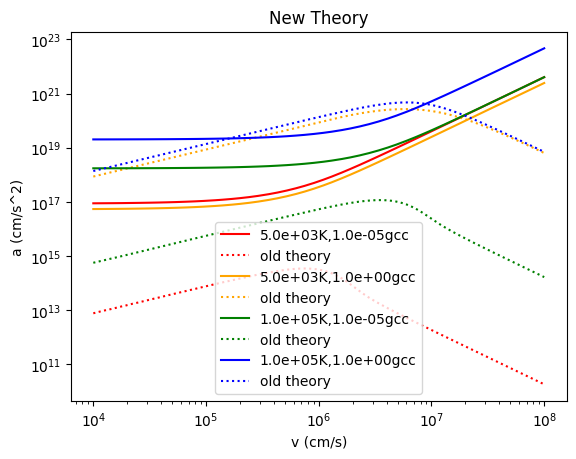

In [8]:
#!/usr/bin/env python3
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
gccarr =  np.array([1e-5,1,1e-5,1],dtype=np.float64)
Tarr = np.array([5000,5000,1e5,1e5],dtype=np.float64)
in_dir = Path("../../theory/2026_03_25")
NA = 6.022e23
pi = 3.1415926535
me = 9.11e-31 #electron mass
ms = 28.0855*0.001/NA
files = sorted(in_dir.glob("*.npy"))
arrs = [np.load(p) for p in files]

dragarr =np.zeros((len(arrs),5))
count = 0
for p in files:
    print(p)
    dragarr[count,0]=float(str(p).split("_")[3].split(".npy")[0])
    dragarr[count,1:] = np.load(p)
    count+=1
indices= dragarr[:,0].argsort()
dragarr = dragarr[indices]
print(dragarr)
colors=["red","orange","green","blue"]

for i in range(4):
    plt.plot(dragarr[:,0]*100,100*dragarr[:,1+i]/ms,color=colors[i],label="{:.1e}K,{:.1e}gcc".format(Tarr[i],gccarr[i]))
    plt.plot(xarr,100*np.abs(FDint(xarr/100,1,Tarr[i],gccarr[i],Z1arr[i],Z2arr[i]))/ms, linestyle=":",color=colors[i],label="old theory")

plt.legend()
# plt.ylim(1e11,1e22)
plt.xscale("log")
plt.title("New Theory")
plt.yscale("log")
plt.xlabel("v (cm/s)")
plt.ylabel("a (cm/s^2)")
plt.show()

[[1.00000000e+02 1.87415687e-18 2.48869528e-14 1.94906292e-17
  1.56328523e-14]
 [1.20000000e+02 1.96562695e-18 2.98636473e-14 2.52223336e-17
  1.87659269e-14]
 [1.50000000e+02 2.80645398e-18 3.73291929e-14 3.29248282e-17
  2.34620118e-14]
 [1.80000000e+02 3.12060901e-18 4.47936657e-14 3.91227309e-17
  2.81528473e-14]
 [2.10000000e+02 3.75361965e-18 5.22578836e-14 4.45188614e-17
  3.28410926e-14]
 [2.60000000e+02 4.69025773e-18 6.46964497e-14 5.29702051e-17
  4.06530452e-14]
 [3.10000000e+02 5.62489084e-18 7.71325753e-14 6.24550321e-17
  4.84680412e-14]
 [3.70000000e+02 6.56406381e-18 9.20517424e-14 7.81550531e-17
  5.78606731e-14]
 [4.50000000e+02 8.20377935e-18 1.11936500e-13 9.41092239e-17
  7.03662814e-14]
 [5.40000000e+02 9.47290083e-18 1.34293076e-13 1.10167218e-16
  8.44280877e-14]
 [6.60000000e+02 1.19436803e-17 1.64076699e-13 1.38467175e-16
  1.03198364e-13]
 [7.90000000e+02 1.39938280e-17 1.96301007e-13 1.62230765e-16
  1.23506691e-13]
 [9.50000000e+02 1.67523930e-17 2.358922

C:\Users\shaoq\AppData\Local\Temp\ipykernel_22844\2146157646.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))*dvrel#/np.sum(frel(vrel,vb,T))


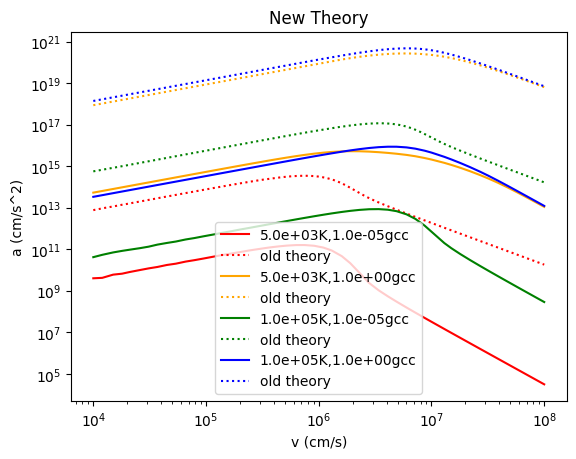

: 

In [ ]:
#!/usr/bin/env python3
from pathlib import Path
import matplotlib.pyplot as plt
in_dir = Path("../../theory/calculation")
NA = 6.022e23
pi = 3.1415926535
me = 9.11e-31 #electron mass
ms = 28.0855*0.001/NA
files = sorted(in_dir.glob("*.npy"))
arrs = [np.load(p) for p in files]

dragarr =np.zeros((len(arrs),5))
count = 0
for p in files:
    dragarr[count,0]=float(str(p).split("_")[1].split(".npy")[0])
    dragarr[count,1:] = np.load(p)
    count+=1
indices= dragarr[:,0].argsort()
dragarr = dragarr[indices]
print(dragarr)
colors=["red","orange","green","blue"]

for i in range(4):
    plt.plot(dragarr[:,0]*100,100*dragarr[:,1+i]/ms,color=colors[i],label="{:.1e}K,{:.1e}gcc".format(Tarr[i],gccarr[i]))
    plt.plot(xarr,100*np.abs(FDint(xarr/100,1,Tarr[i],gccarr[i],Z1arr[i],Z2arr[i]))/ms, linestyle=":",color=colors[i],label="old theory")

plt.legend()
# plt.ylim(1e11,1e22)
plt.xscale("log")
plt.title("New Theory")
plt.yscale("log")
plt.xlabel("v (cm/s)")
plt.ylabel("a (cm/s^2)")
plt.show()